# DecoDen Quick Start Tutorial
In this tutorial, we will use a toy dataset to run DecoDen. 

## Install
The installation of DecoDen is currently offered as a Poetry project while in development. The procedure proposed requires a local installation of git and a C compiler. We recommend the use of Conda to create an environment, with a command such as `conda create -n decoden python>=3.10`. After the activation of the environment (`conda activate decoden`), follow these steps:

### Clone the repository
```bash
git clone git@github.com:ntanmayee/DecoDen.git
cd decoden
```

### Install the external dependencies and DecoDen
```bash
conda install pyarrow poetry
conda install samtools zlib
```
If there is no C compiler installed include also the following command
```bash
conda install c-compiler
poetry install
```

### Change directory
To follow the rest of the tutorial, change directory to `tutorial`
```bash
cd tutorial
```

## Download toy dataset
To run DecoDen, we will use a test dataset from [Jung et. al](https://doi.org/10.1093/nar/gku178), which has already been aligned to `hg19` genome. This dataset contains 2 control replicates, and 3 replicates each for H3K4me3 and H3K27me3. 

To download the dataset from Zenodo, run
```bash
wget https://zenodo.org/records/17055182/files/toy.tar.gz
```
Untar the dataset by running
```bash
tar -xvzf toy.tar.gz
```

This contains 50% subsampled reads for chromosome 1. It also includes the samplesheet (`samples.csv`).
Let's take a quick look at `samples.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
samples = pd.read_csv('toy/samples.csv')
samples

,filepath,exp_name,is_control,replicate,cell_type
0,chr1_50/wce_1_sfilt.bam,control,1,1,e114_deep
1,chr1_50/wce_2_sfilt.bam,control,1,2,e114_deep
2,chr1_50/h3k4me3_1_sfilt.bam,h3k4me3,0,1,e114_deep
3,chr1_50/h3k4me3_2_sfilt.bam,h3k4me3,0,2,e114_deep
4,chr1_50/h3k4me3_3_sfilt.bam,h3k4me3,0,3,e114_deep
5,chr1_50/h3k27me3_1_sfilt.bam,h3k27me3,0,1,e114_deep
6,chr1_50/h3k27me3_2_sfilt.bam,h3k27me3,0,2,e114_deep
7,chr1_50/h3k27me3_3_sfilt.bam,h3k27me3,0,3,e114_deep


## Run DecoDen
```bash
cd toy
decoden run -i samples.csv -o outs_200bp -n 10 -bs 200 -gs hs
```

## Explore results
Let's explore results from NMF.

In [3]:
nmf = pd.read_feather('toy/outs_200bp/NMF/signal_matrix.ftr')
nmf.head()

,seqnames,start,end,tissue_specific,h3k27me3,h3k4me3
0,chr1,1,200,3.187595e-10,0.0,0.0
1,chr1,201,400,3.187595e-10,0.0,0.0
2,chr1,401,600,3.187595e-10,0.0,0.0
3,chr1,601,800,3.187595e-10,0.0,0.0
4,chr1,801,1000,3.187595e-10,0.0,0.0


In [4]:
control = np.load('toy/outs_200bp/data/control_reads.npy')
h3k4me3 = np.load('toy/outs_200bp/data/h3k4me3_reads.npy')
h3k27me3 = np.load('toy/outs_200bp/data/h3k27me3_reads.npy')

raw_data = pd.DataFrame({f'control_{i+1}':control[:,i] for i in range(2)})
for i in range(3):
    raw_data[f'h3k4me3_{i+1}'] = h3k4me3[:,i]
for i in range(3):
    raw_data[f'h3k27me3_{i+1}'] = h3k27me3[:,i]
    
raw_data.head()

,control_1,control_2,h3k4me3_1,h3k4me3_2,h3k4me3_3,h3k27me3_1,h3k27me3_2,h3k27me3_3
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


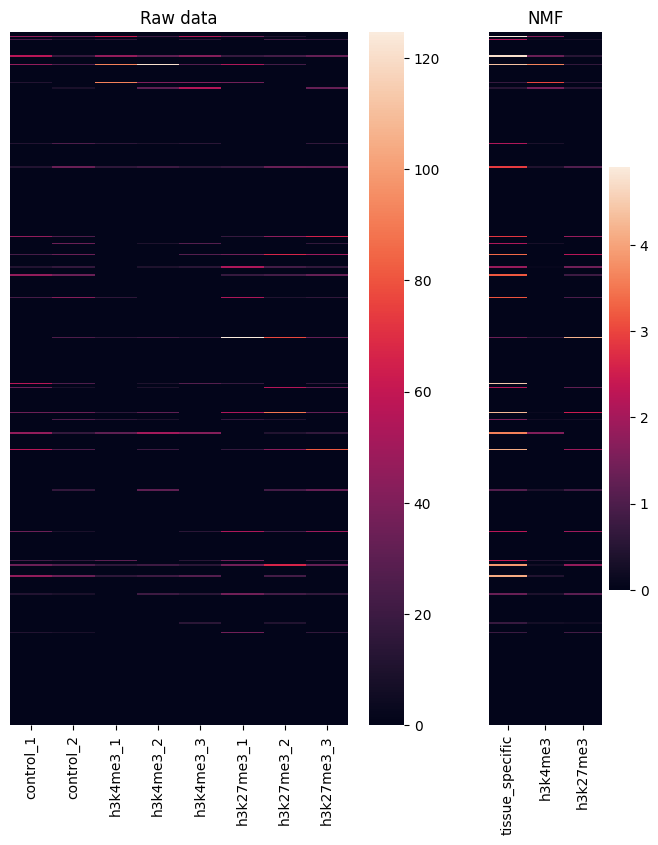

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 9), width_ratios=[3, 1])

# sample 1000 rows (genomic bins) for visualisation
ndxes = raw_data.sample(500, random_state=42).index

sns.heatmap(raw_data.iloc[ndxes], ax=axes[0], yticklabels=False)
sns.heatmap(nmf[['tissue_specific', 'h3k4me3', 'h3k27me3']].iloc[ndxes], ax=axes[1], yticklabels=False)

_ = axes[0].set_title('Raw data')
_ = axes[1].set_title('NMF')

### Mixing matrix

<Axes: >

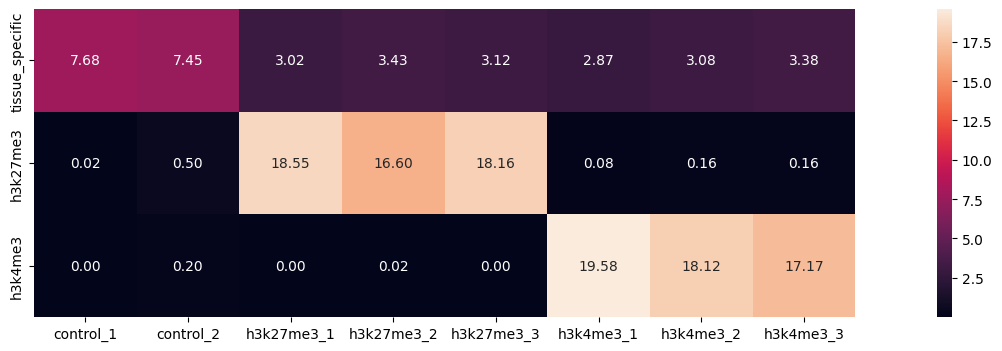

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(21, 4))

mix_mat = pd.read_csv('toy/outs_200bp/NMF/mixing_matrix.csv', index_col=0)
sns.heatmap(mix_mat, annot=True, ax=ax, square=True, fmt='.2f')

In [7]:
mix_mat

,control_1,control_2,h3k27me3_1,h3k27me3_2,h3k27me3_3,h3k4me3_1,h3k4me3_2,h3k4me3_3
tissue_specific,7.679075,7.447743,3.018542,3.428645,3.120610,2.868287,3.080425,3.382246
h3k27me3,0.022057,0.502216,18.548874,16.600120,18.158529,0.081850,0.155349,0.158548
h3k4me3,0.000478,0.200920,0.002976,0.015086,0.000018,19.578400,18.115956,17.173893


## Denoised signal
Final denoised signal is in `outs_200bp/HSR_results.ftr`.

In [8]:
hsr = pd.read_feather('toy/outs_200bp/HSR_results.ftr')
hsr.head()

,seqnames,start,end,h3k27me3 HSR Value,h3k4me3 HSR Value
0,chr1,1,200,1.000000e-19,1.000000e-19
1,chr1,201,400,1.000000e-19,1.000000e-19
2,chr1,401,600,1.000000e-19,1.000000e-19
3,chr1,601,800,1.000000e-19,1.000000e-19
4,chr1,801,1000,1.000000e-19,1.000000e-19
